## Import Libraries

In [1]:
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import tqdm.notebook as tqdm
import mlflow
import mlflow.pytorch
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

project_root = os.path.abspath(os.path.join(os.getcwd(),'..', './'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.data.data_loader import load_datasets, get_dataloaders
from src.data.preprocessing import get_transforms
from src.models.cnn_models import VanillaCNN, DeepCNN
from src.models.resnet_model import FashionResNet
from src.training.trainer import ModelTrainer
from src.evaluation.evaluator import ModelEvaluator
from src.evaluation.visualization import plot_confusion_matrix, plot_training_history
from src.utils.config import load_config
from src.utils.helpers import FASHION_MNIST_CLASSES, get_timestamp_str

print(f"{project_root}")
print(f" Torch Version {torch.__version__}")
print(f" Cuda Availability: {torch.cuda.is_available()}")

H:\VSCode\Python\fashion-mnist-classifier
 Torch Version 2.5.1
 Cuda Availability: True


## Load Configuration

In [2]:
# Point to config.yaml
config = load_config(project_root + '/configs/config.yaml')
device = torch.device("cuda")

# Load configuration from config.yaml
data_config = config['data']
training_config = config['training']
model_config = config['model']
paths_config = config['paths']

# Figures directory for saving plots
os.makedirs(project_root + paths_config['figures_save_dir'], exist_ok=True)

## Get Data

In [3]:
# Get Transform
transform = get_transforms()

# Get Datasets
train_dataset, test_dataset = load_datasets(raw_data_path=project_root + data_config['raw_data_path'], transforms=transform)

Fashion MNIST datasets successfully loaded.  Train Samples: 60000 	 Test Samples: 10000


## Advanced Model Hyperparameter Configuration

In [4]:
advanced_model_configs = {
    'DeepCNN': {
                    'model_class': DeepCNN,
                    'Description': 'Deep CNN with BatchNorm and Dropout',
                    'hyperparams': [
                                    {'lr':  0.001, 'epochs': 20, 'batch_size': 32, 'dropout': 0.3},
                                    {'lr': 0.005, 'epochs':15, 'batch_size': 64, 'dropout': 0.4},
                                    {'lr': 0.0005, 'epochs': 10, 'batch_size': 128, 'dropout': 0.35}
                                    ]
                },
                'FashionResNet':{
                    'model_class': FashionResNet,
                    'Description': 'ResNet-like architecture with residual connections',
                    'hyperparams': [
                                    {'lr': 0.001, 'epochs': 20, 'batch_size': 32, 'blocks': [2,2,2]},
                                    {'lr': 0.005, 'epochs': 15, 'batch_size': 64, 'blocks': [2,2,2]}, 
                                    {'lr': 0.01, 'epochs': 10, 'batch_size': 128, 'blocks': [3,3,3]}
                                    ]
                }
    }

# Storage for analysis
experiment_results = {}

## Training Function with MLflow

In [5]:
def train_advanced_model(model_name, model_class, hyperparams, experiment_name, train_dataset, test_dataset):
    """
    Train models with specified hyperparameters.
    """
    # Set MLflow Experiment
    mlflow.set_experiment(f"Advanced_Models_{experiment_name}")

    results = []

    for i, params in enumerate(hyperparams):
        print(f" Training {model_name} - Configuration {i+1} of {len(hyperparams)}")
        print(f" Learning Rate: {params['lr']}")
        print(f" Epochs: {params['epochs']}")
        print(f" Batch Size: {params['batch_size']}")

        with mlflow.start_run(run_name=f"{model_name}_advanced_config_{i+1}"):
            # Load Hyperparameters
            mlflow.log_params({
                                'model_name': model_name,
                                'learning_rate': params['lr'],
                                'epochs': params['epochs'],
                                'batch_size': params['batch_size'],
                                'config_id': {i+1},
                                'experiment_type': 'advanced_architecture'})
            
            # Prepare data with specified batch size
            train_loader, test_loader = get_dataloaders(train_dataset, test_dataset,
                                                        batch_size=params['batch_size'],
                                                        num_workers=training_config['num_workers'], 
                                                        pin_memory=training_config['pin_memory'])
            
            # Initialize Model
            model = model_class(tuple(data_config['input_shape']), num_classes=10)
            model.to(device)
    
            # Setup Optimizer and Loss Function
            optimizer = optim.Adam(model.parameters(), lr=params['lr'])
            criterion = nn.CrossEntropyLoss()
    
            # Use ModelTrainer
            trainer = ModelTrainer(model, device)
    
            # Tracking Training Loop
            history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
            best_val_acc = 0.0
    
            for epoch in range(1, 1 + params['epochs']):
                train_loss, train_acc = trainer.train_mode(train_loader, optimizer, criterion)
                val_loss, val_acc = trainer.validate_mode(test_loader, criterion)
    
                # Store History
                history['train_loss'].append(train_loss)
                history['train_acc'].append(train_acc)
                history['val_loss'].append(val_loss)
                history['val_acc'].append(val_acc)
    
                # MLflow Log
                mlflow.log_metrics({
                                    'train_loss': train_loss,
                                    'train_accuracy': train_acc,
                                    'val_loss': val_loss,
                                    'val_accuracy': val_acc},
                                  step=epoch)
    
                # Update Best Validation Accuracy
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
    
                # Progress Update
                if epoch == params['epochs']:
                    print(f" Epoch: {epoch:2d} \t Train Loss: {train_loss:.4f}\n",
                          f" Train Accuracy: {train_acc} \t Validation Loss: {val_loss}\n",
                          f" Validation Accuracy: {val_acc}")
    
                # Evaluator Pattern
                evaluator = ModelEvaluator(model, device)
                y_true, y_pred = evaluator.get_labels(test_loader)
                last_test_accuracy = (y_true == y_pred) / len(y_true)
    
                # Log Metrics
                mlflow.log_metrics({'last_test_accuracy': last_test_accuracy,
                                    'best_val_acc': best_val_acc})
    
                # Log Artifacts
                mlflow.pytorch.log_model(model, f"{model_name}_advanced_model")
    
                # Store Results
                result = {'model_name': model_name,
                            'config_id': i+1,
                            'hyperparams': params,
                            'best_val_acc': best_val_acc,
                            'last_test_accuracy': last_test_accuracy,
                            'history': history,
                            'model': model}
    
                results.append(result)
                print(f" Configuration {i+1} - Best Validation Accuracy: {best_val_acc:.4f}")
    return results

## DeepCNN Configurations

In [6]:
deepcnn_results = train_advanced_model(model_name = 'DeepCNN',
                                       model_class = DeepCNN,
                                       hyperparams=advanced_model_configs['DeepCNN']['hyperparams'],
                                       experiment_name = 'DeepCNN-Advance',
                                       train_dataset = train_dataset, 
                                       test_dataset = test_dataset)

experiment_results['DeepCNN'] = deepcnn_results

2025/08/17 10:42:06 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



 Training DeepCNN - Configuration 1 of 3
 Learning Rate: 0.001
 Epochs: 20
 Batch Size: 32
DataLoaders created with batch size: 32


Validation: 100%|██████████| 313/313 [00:05<00:00, 53.80it/s] 
2025/08/17 10:42:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/08/17 10:42:38 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


 Configuration 1 - Best Validation Accuracy: 0.8890


Validation: 100%|██████████| 313/313 [00:05<00:00, 54.35it/s] 
2025/08/17 10:43:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/08/17 10:43:08 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


...

 Configuration 3 - Best Validation Accuracy: 0.9293


Validation: 100%|██████████| 79/79 [00:06<00:00, 12.56it/s]


 Epoch: 10 	 Train Loss: 0.0758
  Train Accuracy: 0.9716666666666667 	 Validation Loss: 0.2611367149353027
  Validation Accuracy: 0.9276


2025/08/17 12:35:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/08/17 12:35:55 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


 Configuration 3 - Best Validation Accuracy: 0.9293


## FashionResNet Configurations

In [7]:
resnet_results = train_advanced_model(model_name='FashionResNet',
                                      model_class=FashionResNet,
                                      hyperparams=advanced_model_configs['FashionResNet']['hyperparams'],
                                      experiment_name='ResNet_Advanced',
                                      train_dataset = train_dataset, 
                                      test_dataset = test_dataset)

experiment_results['FashionResNet'] = resnet_results

 Training FashionResNet - Configuration 1 of 3
 Learning Rate: 0.001
 Epochs: 20
 Batch Size: 32
DataLoaders created with batch size: 32


Validation: 100%|██████████| 313/313 [00:07<00:00, 42.49it/s] 
2025/08/17 12:36:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/08/17 12:36:43 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


 Configuration 1 - Best Validation Accuracy: 0.8910


Validation: 100%|██████████| 313/313 [00:07<00:00, 42.16it/s] 
2025/08/17 12:37:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/08/17 12:37:30 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


 Configuration 1 - Best Validation Accuracy: 0.9088


...

 Configuration 3 - Best Validation Accuracy: 0.9276


Validation: 100%|██████████| 79/79 [00:06<00:00, 11.80it/s]


 Epoch: 10 	 Train Loss: 0.0986
  Train Accuracy: 0.9636 	 Validation Loss: 0.2582563237190247
  Validation Accuracy: 0.918


2025/08/17 14:39:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/08/17 14:39:41 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


 Configuration 3 - Best Validation Accuracy: 0.9276


## Comprehensive Advanced Model Analysis


DeepCNN - Best Advanced Configuration:
   Config ID: 1
   Hyperparams: {'lr': 0.001, 'epochs': 20, 'batch_size': 32, 'dropout': 0.3}
   Best Val Accuracy: 0.9306
   Final Test Accuracy: 0.0000

FashionResNet - Best Advanced Configuration:
   Config ID: 1
   Hyperparams: {'lr': 0.001, 'epochs': 20, 'batch_size': 32, 'blocks': [2, 2, 2]}
   Best Val Accuracy: 0.9333
   Final Test Accuracy: 0.0000


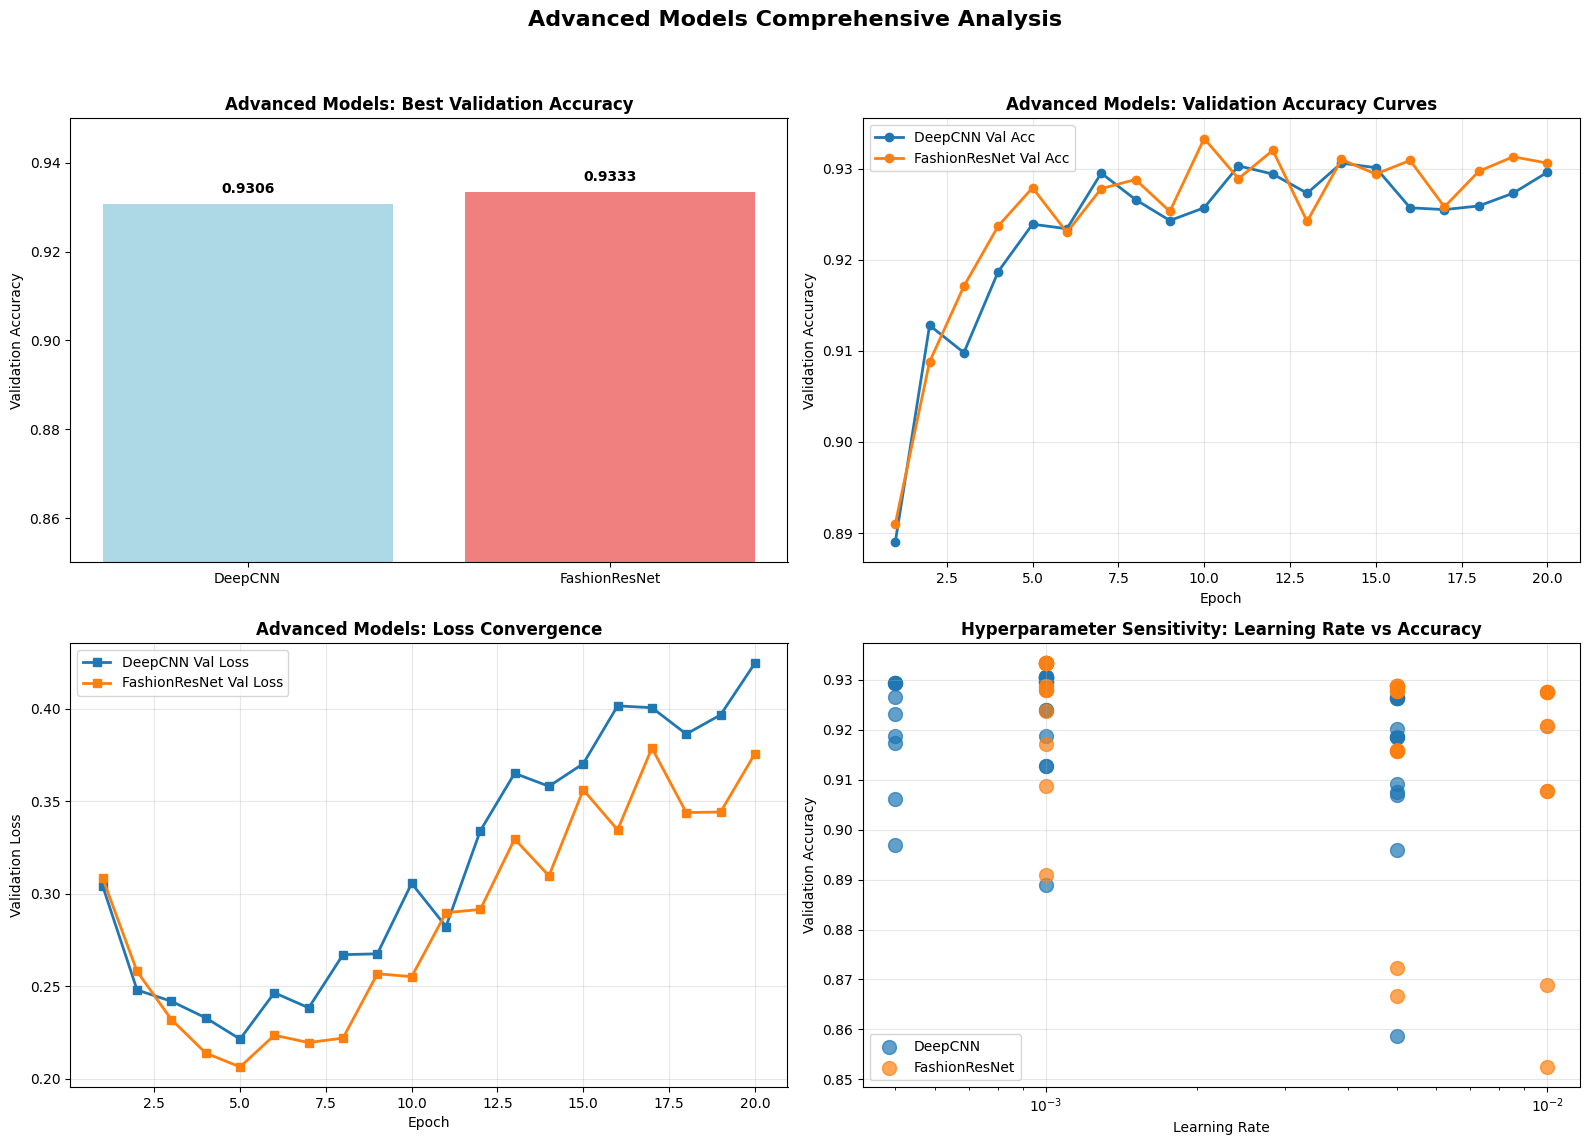

Advanced models analysis plot saved to: H:\VSCode\Python\fashion-mnist-classifier/results/figures\advanced_models_analysis_20250817_154633.png


In [10]:
# Find best configuration for each advanced model
best_advanced_models = {}
for model_name, results in experiment_results.items():
    best_config = max(results, key=lambda x: x['best_val_acc'])
    best_advanced_models[model_name] = best_config
    
    print(f"\n{model_name} - Best Advanced Configuration:")
    print(f"   Config ID: {best_config['config_id']}")
    print(f"   Hyperparams: {best_config['hyperparams']}")
    print(f"   Best Val Accuracy: {best_config['best_val_acc']:.4f}")
    print(f"   Final Test Accuracy: {best_config['last_test_accuracy']:.4f}")

# Advanced visualization with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Advanced model performance comparison
model_names = list(best_advanced_models.keys())
best_val_accs = [best_advanced_models[name]['best_val_acc'] for name in model_names]

axes[0, 0].bar(model_names, best_val_accs, color=['lightblue', 'lightcoral'])
axes[0, 0].set_title('Advanced Models: Best Validation Accuracy', fontweight='bold')
axes[0, 0].set_ylabel('Validation Accuracy')
axes[0, 0].set_ylim(0.85, 0.95)

# Add value labels on bars
for i, v in enumerate(best_val_accs):
    axes[0, 0].text(i, v + 0.002, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Learning curves for best advanced models
for model_name, best_config in best_advanced_models.items():
    history = best_config['history']
    epochs = range(1, len(history['val_acc']) + 1)
    axes[0, 1].plot(epochs, history['val_acc'], label=f'{model_name} Val Acc', marker='o', linewidth=2)

axes[0, 1].set_title('Advanced Models: Validation Accuracy Curves', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Loss convergence comparison
for model_name, best_config in best_advanced_models.items():
    history = best_config['history']
    epochs = range(1, len(history['val_loss']) + 1)
    axes[1, 0].plot(epochs, history['val_loss'], label=f'{model_name} Val Loss', marker='s', linewidth=2)

axes[1, 0].set_title('Advanced Models: Loss Convergence', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Validation Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Hyperparameter sensitivity analysis
all_results = []
for model_name, results in experiment_results.items():
    for result in results:
        all_results.append({
            'Model': model_name,
            'Learning Rate': result['hyperparams']['lr'],
            'Val Accuracy': result['best_val_acc'],
            'Config': f"Config {result['config_id']}"
        })

df_results = pd.DataFrame(all_results)

for model in df_results['Model'].unique():
    model_data = df_results[df_results['Model'] == model]
    axes[1, 1].scatter(model_data['Learning Rate'], model_data['Val Accuracy'], 
                      label=model, s=100, alpha=0.7)

axes[1, 1].set_title('Hyperparameter Sensitivity: Learning Rate vs Accuracy', fontweight='bold')
axes[1, 1].set_xlabel('Learning Rate')
axes[1, 1].set_ylabel('Validation Accuracy')
axes[1, 1].set_xscale('log')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Advanced Models Comprehensive Analysis', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save Plots
timestamp = get_timestamp_str()
analysis_plot_path = os.path.join(project_root + '/results/figures', f'advanced_models_analysis_{timestamp}.png')
plt.savefig(analysis_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Advanced models analysis plot saved to: {analysis_plot_path}")

## Architecture Complexity v Performance Analysis

Complexity v Performance Summary:


,Model,Accuracy,Complexity_Score,Estimated_Params,Key_Features
0,DeepCNN,0.9306,3,~500K,BatchNorm + Dropout
1,FashionResNet,0.9333,5,~1M,Residual Connections + BatchNorm


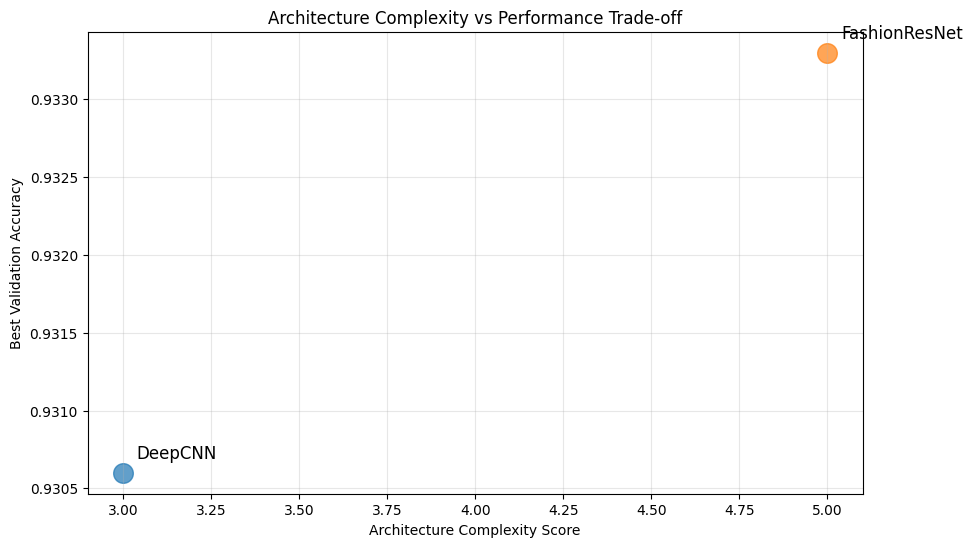

Complexity Analysis Plot saved to: /results/figures/complexity_vs_performance_20250817_154633.png


In [11]:
# Define complexity metrics for each model (approximate)
model_complexity_metrics = {
    'DeepCNN': {
        'layers': 6,  # 3 conv + 3 linear layers
        'params_estimate': '~500K',
        'training_features': 'BatchNorm + Dropout',
        'complexity_score': 3
    },
    'FashionResNet': {
        'layers': 12,  # Multiple residual blocks
        'params_estimate': '~1M',
        'training_features': 'Residual Connections + BatchNorm',
        'complexity_score': 5
    }
}

# Performance v Complexity Comparison
complexity_analysis = []
for model_name, config in best_advanced_models.items():
    complexity = model_complexity_metrics.get(model_name, {})
    complexity_analysis.append({
        'Model': model_name,
        'Accuracy': config['best_val_acc'],
        'Complexity_Score': complexity.get('complexity_score', 0),
        'Estimated_Params': complexity.get('params_estimate', 'Unknown'),
        'Key_Features': complexity.get('training_features', 'Standard')
    })

complexity_df = pd.DataFrame(complexity_analysis)
print("Complexity v Performance Summary:")
display(complexity_df)

# Visualize complexity vs performance trade-off
plt.figure(figsize=(10, 6))
for _, row in complexity_df.iterrows():
    plt.scatter(row['Complexity_Score'], row['Accuracy'], s=200, alpha=0.7)
    plt.annotate(row['Model'], 
                (row['Complexity_Score'], row['Accuracy']),
                xytext=(10, 10), textcoords='offset points', fontsize=12)

plt.xlabel('Architecture Complexity Score')
plt.ylabel('Best Validation Accuracy')
plt.title('Architecture Complexity vs Performance Trade-off')
plt.grid(True, alpha=0.3)

complexity_plot_path = f'/results/figures/complexity_vs_performance_{timestamp}.png'
plt.savefig(project_root + complexity_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Complexity Analysis Plot saved to: {complexity_plot_path}")